<a href="https://colab.research.google.com/github/VInitha24057/task-07/blob/main/task_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Task 7 — AI Tool Adoption Trend Analysis**

# Installing necessary libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print(" All libraries imported successfully!")
print(f"Pandas : {pd.__version__}  |  NumPy : {np.__version__}")

 All libraries imported successfully!
Pandas : 2.2.2  |  NumPy : 2.0.2


# New Section
Uploadidng dataset
1. Phase 1: Data Understanding    




In [ ]:
df = pd.read_csv("/content/AI_Adoption_Survey_Dataset_500.csv")
print("Shape")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n Data Types")
print(df.dtypes)

print("\n Missing Values")
print(df.isnull().sum())

print(f"\n Duplicate Rows: {df.duplicated().sum()} ")

print(f"\n Organisations Surveyed : {df['org_id'].nunique()}")
print(f"\nTop 5 AI Tools:\n{df['primary_ai_tool'].value_counts().head()}")
print(f"\nAdoption by Industry:\n{df['industry'].value_counts()}")

Shape
Rows: 500, Columns: 15

 Data Types
org_id                     int64
industry                  object
primary_ai_tool           object
company_size              object
employee_count             int64
adoption_year              int64
ai_investment_usd          int64
productivity_gain_pct    float64
satisfaction_score       float64
cost_savings_usd           int64
num_ai_tools_used          int64
adoption_rate_pct        float64
training_hours             int64
has_ai_strategy            int64
size_num                   int64
dtype: object

 Missing Values
org_id                   0
industry                 0
primary_ai_tool          0
company_size             0
employee_count           0
adoption_year            0
ai_investment_usd        0
productivity_gain_pct    0
satisfaction_score       0
cost_savings_usd         0
num_ai_tools_used        0
adoption_rate_pct        0
training_hours           0
has_ai_strategy          0
size_num                 0
dtype: int64

 Duplicate Ro

Phase 2: Descriptive **Statistics**

In [ ]:
numeric_cols = ['productivity_gain_pct','adoption_rate_pct',
                'satisfaction_score','ai_investment_usd','cost_savings_usd']

print("── Descriptive Statistics ──")
desc = df[numeric_cols].describe(percentiles=[.25, .50, .75, .90])
print(desc.round(2))

print(f"\n Avg Productivity Gain : {df['productivity_gain_pct'].mean():.2f}%")
print(f" Median Adoption Rate  : {df['adoption_rate_pct'].median():.2f}%")
print(f" Avg AI Investment     : ${df['ai_investment_usd'].mean():,.0f}")
print(f" Avg Cost Savings      : ${df['cost_savings_usd'].mean():,.0f}")


── Descriptive Statistics ──
       productivity_gain_pct  adoption_rate_pct  satisfaction_score  \
count                 500.00             500.00              500.00   
mean                   37.82              62.55                7.13   
std                    10.49              18.30                1.44   
min                     5.88              12.16                2.83   
25%                    30.59              49.70                6.11   
50%                    38.48              63.15                7.05   
75%                    44.75              75.86                8.21   
90%                    50.90              85.81                9.10   
max                    63.72             100.00               10.00   

       ai_investment_usd  cost_savings_usd  
count             500.00            500.00  
mean            49400.02         116702.30  
std             92306.46         269264.27  
min               378.00            427.00  
25%             10406.50          2

 Phase 3: Trend Investigation


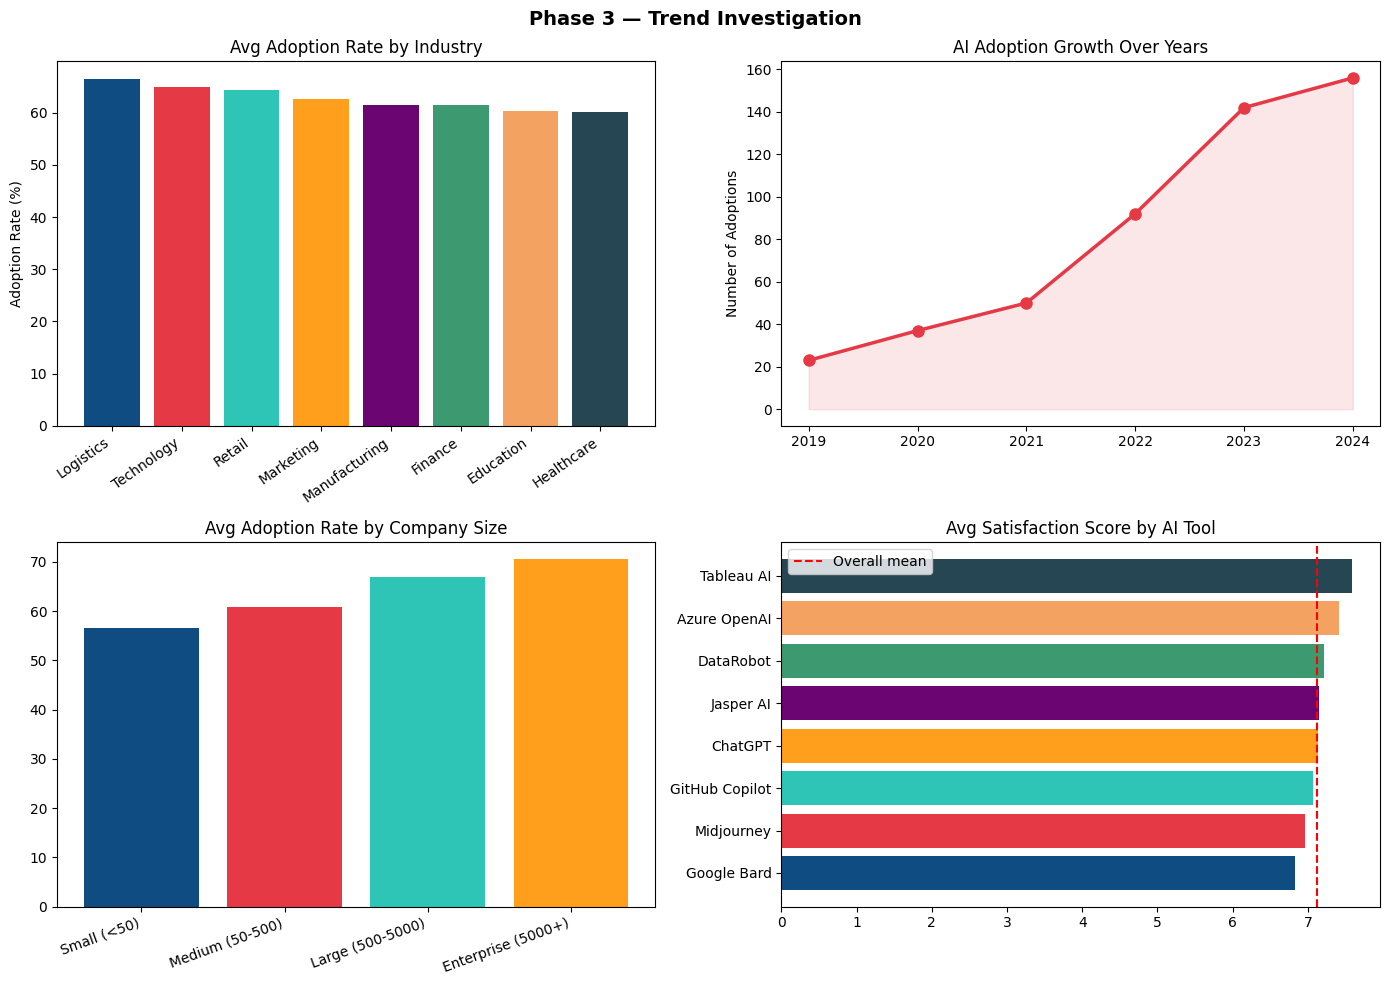

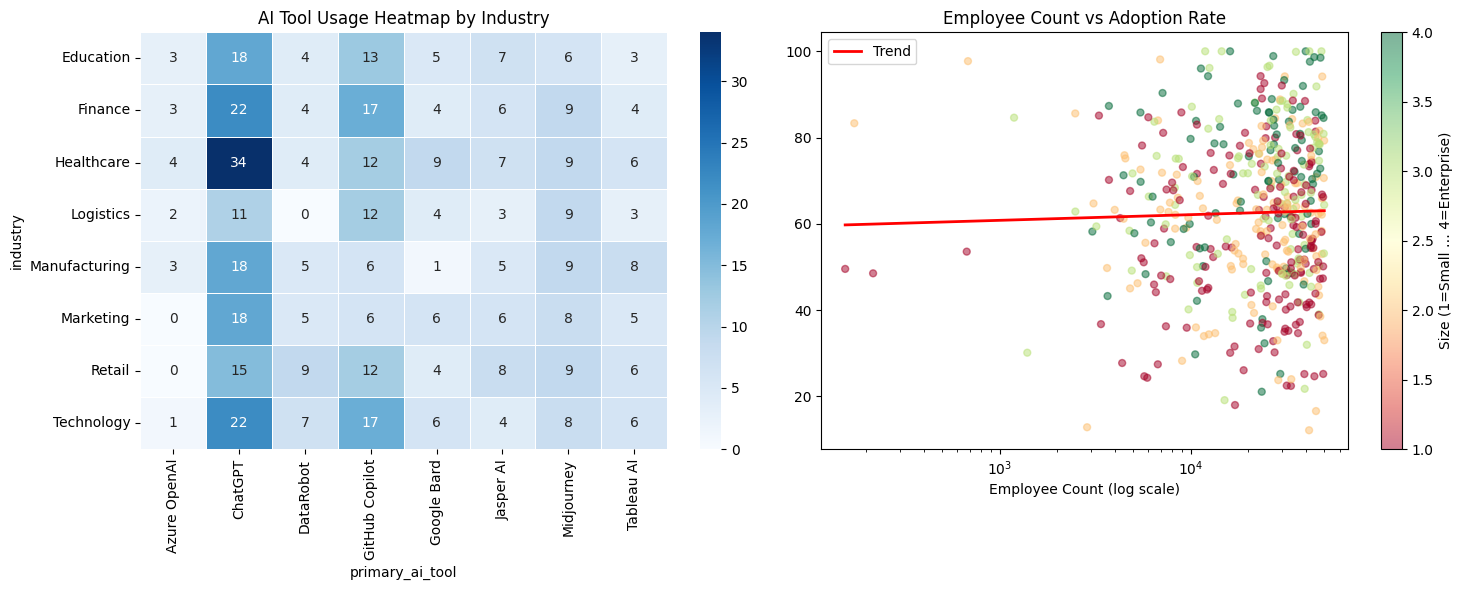

In [ ]:
PALETTE8 = ['#0F4C81','#E63946','#2EC4B6','#FF9F1C',
            '#6A0572','#3D9970','#F4A261','#264653']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Phase 3 — Trend Investigation', fontsize=14, fontweight='bold')

# 1. Industry vs Adoption Rate (Bar chart)
ind_adopt = df.groupby('industry')['adoption_rate_pct'].mean().sort_values(ascending=False)
axes[0,0].bar(ind_adopt.index, ind_adopt.values, color=PALETTE8)
axes[0,0].set_title('Avg Adoption Rate by Industry')
axes[0,0].set_xticklabels(ind_adopt.index, rotation=35, ha='right')
axes[0,0].set_ylabel('Adoption Rate (%)')

# 2. Adoption Year → Growth Trend (Line chart + fill)
year_adopt = df.groupby('adoption_year').size().reset_index(name='count')
axes[0,1].plot(year_adopt['adoption_year'], year_adopt['count'],
              marker='o', color='#E63946', linewidth=2.5, markersize=8)
axes[0,1].fill_between(year_adopt['adoption_year'], year_adopt['count'],
                        alpha=0.12, color='#E63946')
axes[0,1].set_title('AI Adoption Growth Over Years')
axes[0,1].set_ylabel('Number of Adoptions')

# 3. Company Size vs Adoption Rate
size_adopt = df.groupby('company_size')['adoption_rate_pct'].mean().reindex(size_order)
axes[1,0].bar(size_order, size_adopt, color=PALETTE8[:4])
axes[1,0].set_title('Avg Adoption Rate by Company Size')
axes[1,0].set_xticklabels(size_order, rotation=20, ha='right')

# 4. AI Tool vs Satisfaction Score (Horizontal bar)
tool_sat = df.groupby('primary_ai_tool')['satisfaction_score'].mean().sort_values()
axes[1,1].barh(tool_sat.index, tool_sat.values, color=PALETTE8)
axes[1,1].set_title('Avg Satisfaction Score by AI Tool')
axes[1,1].axvline(df['satisfaction_score'].mean(),
                  color='red', linestyle='--', label='Overall mean')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('phase3_trends.png', dpi=120, bbox_inches='tight')
plt.show()

# Heatmap: Industry × AI Tool usage frequency
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

pivot = df.groupby(['industry','primary_ai_tool']).size().unstack(fill_value=0)
sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues',
            ax=axes[0], linewidths=0.4)
axes[0].set_title('AI Tool Usage Heatmap by Industry')

# Scatter: Employee Count vs Adoption Rate
sc = axes[1].scatter(df['employee_count'], df['adoption_rate_pct'],
                     c=df['size_num'], cmap='RdYlGn', alpha=0.5, s=25)
plt.colorbar(sc, ax=axes[1], label='Size (1=Small … 4=Enterprise)')
axes[1].set_xscale('log')
axes[1].set_title('Employee Count vs Adoption Rate')
axes[1].set_xlabel('Employee Count (log scale)')

m, b = np.polyfit(np.log10(df['employee_count']+1), df['adoption_rate_pct'], 1)
xs = np.linspace(df['employee_count'].min(), df['employee_count'].max(), 200)
axes[1].plot(xs, m*np.log10(xs+1)+b, color='red', linewidth=2, label='Trend')
axes[1].legend()

plt.tight_layout()
plt.savefig('phase3_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

Phase 4: Correlation Analysis

In [ ]:
corr_cols = ['adoption_rate_pct','productivity_gain_pct',
             'satisfaction_score','ai_investment_usd',
             'cost_savings_usd','employee_count','size_num']
corr_matrix = df[corr_cols].corr()
print("── Correlation Matrix ──")
print(corr_matrix.round(3))

# Key Pearson correlations with p-values
r1,p1 = stats.pearsonr(df['adoption_rate_pct'], df['productivity_gain_pct'])
r2,p2 = stats.pearsonr(df['size_num'],           df['adoption_rate_pct'])
r3,p3 = stats.pearsonr(df['ai_investment_usd'],  df['cost_savings_usd'])

print(f"\n Adoption ↔ Productivity  r={r1:.3f}, p={p1:.4f}",
      " Significant" if p1<0.05 else "Not significant")
print(f" Size     ↔ Adoption Rate  r={r2:.3f}, p={p2:.4f}",
      "Significant" if p2<0.05 else "Not significant")
print(f" Investment ↔ Savings      r={r3:.3f}, p={p3:.4f}",
      "Significant" if p3<0.05 else "Not significant")

── Correlation Matrix ──
                       adoption_rate_pct  productivity_gain_pct  \
adoption_rate_pct                  1.000                  0.278   
productivity_gain_pct              0.278                  1.000   
satisfaction_score                -0.092                 -0.008   
ai_investment_usd                 -0.037                 -0.112   
cost_savings_usd                  -0.044                 -0.119   
employee_count                     0.028                  0.017   
size_num                           0.289                  0.077   

                       satisfaction_score  ai_investment_usd  \
adoption_rate_pct                  -0.092             -0.037   
productivity_gain_pct              -0.008             -0.112   
satisfaction_score                  1.000             -0.028   
ai_investment_usd                  -0.028              1.000   
cost_savings_usd                   -0.031              0.961   
employee_count                      0.007             

 Phase 5: Hypothesis Testing

In [ ]:
groups = [g['adoption_rate_pct'].values
          for _, g in df.groupby('company_size')]
f_stat, p_val = stats.f_oneway(*groups)


print(" ONE-WAY ANOVA TEST")

print(f" H₀ : Company size has NO impact on AI adoption")
print(f" H₁ : Company size SIGNIFICANTLY impacts AI adoption")

print(f" F-statistic : {f_stat:.4f}")
print(f" p-value     : {p_val:.6f}")
print(f" α (alpha)   : 0.05")

if p_val < 0.05:
    print(" Decision  :  REJECT H₀")
    print(" Business  : Company size significantly impacts AI adoption")


print("\nGroup Mean Adoption Rates:")
print(df.groupby('company_size')['adoption_rate_pct']
        .mean().reindex(size_order).round(2))

 ONE-WAY ANOVA TEST
 H₀ : Company size has NO impact on AI adoption
 H₁ : Company size SIGNIFICANTLY impacts AI adoption
 F-statistic : 15.2075
 p-value     : 0.000000
 α (alpha)   : 0.05
 Decision  :  REJECT H₀
 Business  : Company size significantly impacts AI adoption

Group Mean Adoption Rates:
company_size
Small (<50)           56.66
Medium (50-500)       60.89
Large (500-5000)      67.03
Enterprise (5000+)    70.49
Name: adoption_rate_pct, dtype: float64


[Text(0, 0, 'Small (<50)'),
 Text(1, 0, 'Medium (50-500)'),
 Text(2, 0, 'Large (500-5000)'),
 Text(3, 0, 'Enterprise (5000+)')]

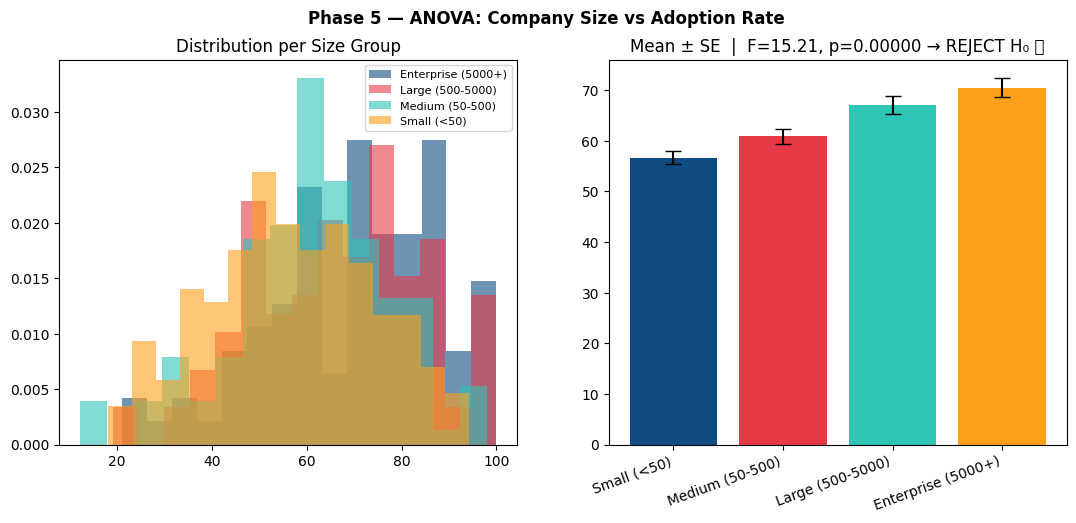

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Phase 5 — ANOVA: Company Size vs Adoption Rate', fontweight='bold')

for i, (sz, grp) in enumerate(df.groupby('company_size')):
    axes[0].hist(grp['adoption_rate_pct'], bins=15, alpha=0.6,
                color=PALETTE8[i], label=sz, density=True)
axes[0].set_title('Distribution per Size Group'); axes[0].legend(fontsize=8)

means = df.groupby('company_size')['adoption_rate_pct'].mean().reindex(size_order)
sems  = df.groupby('company_size')['adoption_rate_pct'].sem().reindex(size_order)
axes[1].bar(size_order, means, yerr=sems, capsize=6, color=PALETTE8[:4])
axes[1].set_title(f'Mean ± SE  |  F={f_stat:.2f}, p={p_val:.5f} → REJECT H₀ ')
axes[1].set_xticklabels(size_order, rotation=20, ha='right')

 Phase 6: Segmentation

In [ ]:
def segment_org(row):
    if row['adoption_rate_pct'] >= 75 and row['productivity_gain_pct'] >= 40:
        return 'AI Leader'
    elif row['adoption_rate_pct'] >= 55 and row['adoption_year'] <= 2021:
        return 'Early Adopter'
    elif row['satisfaction_score'] >= 8.5:
        return 'High Satisfaction'
    elif (row['cost_savings_usd'] / max(row['ai_investment_usd'], 1)) >= 2.5:
        return 'High ROI'
    elif row['adoption_rate_pct'] < 35:
        return 'Slow Adopter'
    else:
        return 'Mainstream'

df['segment'] = df.apply(segment_org, axis=1)

print("── Segment Counts ──")
print(df['segment'].value_counts())

print("\n── Avg Metrics per Segment ──")
print(df.groupby('segment')[['adoption_rate_pct','productivity_gain_pct',
                               'satisfaction_score']].mean().round(2))

── Segment Counts ──
segment
Mainstream           165
High ROI             114
AI Leader             76
High Satisfaction     72
Early Adopter         58
Slow Adopter          15
Name: count, dtype: int64

── Avg Metrics per Segment ──
                   adoption_rate_pct  productivity_gain_pct  \
segment                                                       
AI Leader                      85.75                  48.90   
Early Adopter                  69.48                  35.66   
High ROI                       55.89                  35.43   
High Satisfaction              54.86                  36.66   
Mainstream                     60.50                  35.78   
Slow Adopter                   28.22                  36.22   

                   satisfaction_score  
segment                                
AI Leader                        6.89  
Early Adopter                    7.13  
High ROI                         6.58  
High Satisfaction                9.26  
Mainstream         

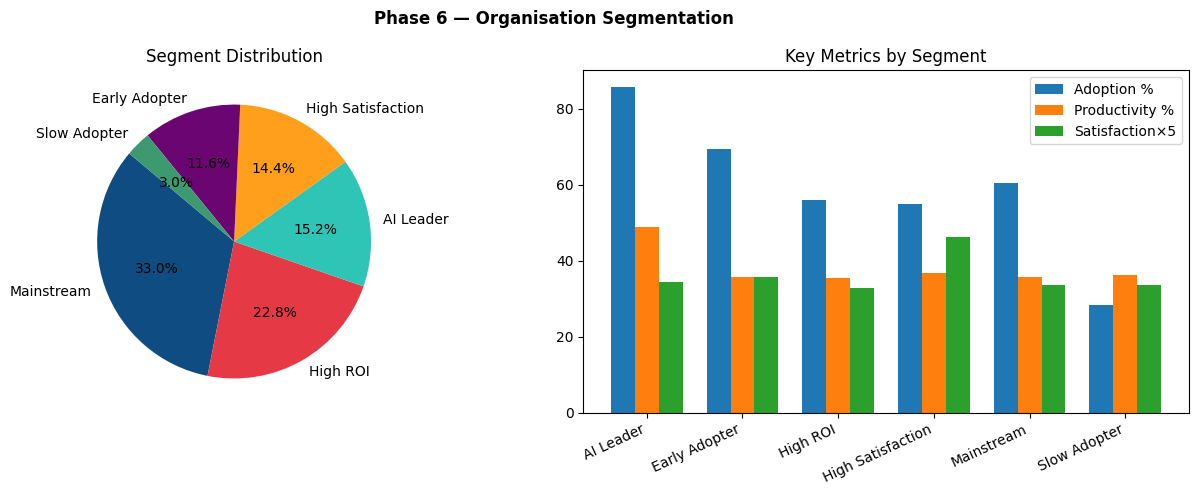

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Phase 6 — Organisation Segmentation', fontweight='bold')

seg_counts = df['segment'].value_counts()
axes[0].pie(seg_counts.values, labels=seg_counts.index,
            autopct='%1.1f%%', colors=PALETTE8, startangle=140)
axes[0].set_title('Segment Distribution')

seg_m = df.groupby('segment')[['adoption_rate_pct',
           'productivity_gain_pct','satisfaction_score']].mean()
x = np.arange(len(seg_m)); w = 0.25
axes[1].bar(x-w, seg_m['adoption_rate_pct'],     width=w, label='Adoption %')
axes[1].bar(x,   seg_m['productivity_gain_pct'], width=w, label='Productivity %')
axes[1].bar(x+w, seg_m['satisfaction_score']*5, width=w, label='Satisfaction×5')
axes[1].set_xticks(x)
axes[1].set_xticklabels(seg_m.index, rotation=25, ha='right')
axes[1].legend(); axes[1].set_title('Key Metrics by Segment')
plt.tight_layout(); plt.savefig('phase6_segments.png', dpi=120); plt.show()

Phase 7: Business Insights

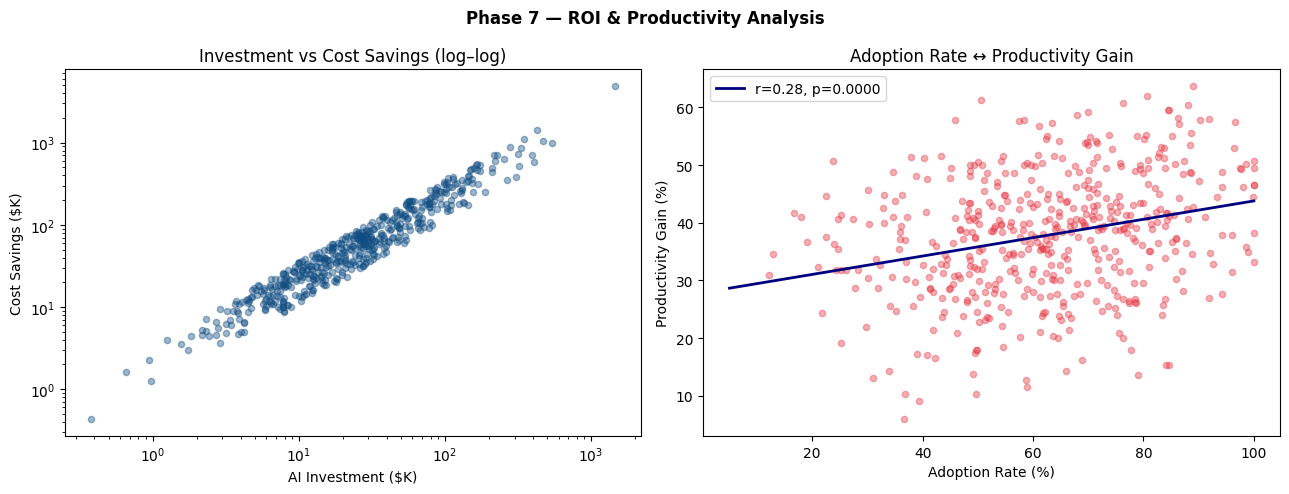

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Phase 7 — ROI & Productivity Analysis', fontweight='bold')

axes[0].scatter(df['ai_investment_usd']/1000, df['cost_savings_usd']/1000,
               alpha=0.4, c='#0F4C81', s=20)
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_xlabel('AI Investment ($K)'); axes[0].set_ylabel('Cost Savings ($K)')
axes[0].set_title('Investment vs Cost Savings (log–log)')

axes[1].scatter(df['adoption_rate_pct'], df['productivity_gain_pct'],
               alpha=0.4, c='#E63946', s=20)
r, p = stats.pearsonr(df['adoption_rate_pct'], df['productivity_gain_pct'])
m, b = np.polyfit(df['adoption_rate_pct'], df['productivity_gain_pct'], 1)
xs = np.linspace(5, 100, 100)
axes[1].plot(xs, m*xs+b, color='navy', linewidth=2, label=f'r={r:.2f}, p={p:.4f}')
axes[1].set_xlabel('Adoption Rate (%)'); axes[1].set_ylabel('Productivity Gain (%)')
axes[1].set_title('Adoption Rate ↔ Productivity Gain'); axes[1].legend()

plt.tight_layout()
plt.savefig('phase7_roi_productivity.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
print("\n All 7 phases complete!")


 All 7 phases complete!


In [ ]:
!git config --global user.name "VInitha24057"
!git config --global user.email "hariharan2254@gmail.com"

In [ ]:
!git clone https://github.com/VInitha24057/task-07.git

Cloning into 'task-07'...


In [ ]:
%cd task-07/


/content/task-07


In [ ]:
from google.colab import drive
